In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error , r2_score

In [3]:
import pandas as pd

In [4]:
df = pd.read_csv("Housing.csv")

In [6]:
print(df.head())

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


In [7]:
print(df.isnull())

     price   area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0    False  False     False      False    False     False      False   
1    False  False     False      False    False     False      False   
2    False  False     False      False    False     False      False   
3    False  False     False      False    False     False      False   
4    False  False     False      False    False     False      False   
..     ...    ...       ...        ...      ...       ...        ...   
540  False  False     False      False    False     False      False   
541  False  False     False      False    False     False      False   
542  False  False     False      False    False     False      False   
543  False  False     False      False    False     False      False   
544  False  False     False      False    False     False      False   

     basement  hotwaterheating  airconditioning  parking  prefarea  \
0       False            False            False    False     Fals

In [8]:
df = df.dropna()

In [14]:
df = pd.get_dummies(df , drop_first=True)
df.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [15]:
# X = df[['area','bedrooms','bathrooms','parking','stories']]
X = df.drop('price',axis=1)

In [16]:
Y = df['price']

In [17]:
X_train , X_test , Y_train , Y_test = train_test_split(
    X , Y ,test_size=0.2, random_state=42
)

In [18]:
model = LinearRegression()

In [24]:
model.fit(X_train , Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [25]:
Y_predict= model.predict(X_test)

In [26]:
MSE = mean_squared_error(Y_test,Y_predict)
r2 = r2_score(Y_test,Y_predict)

In [27]:
print("MSE: ",MSE)
print("r2: ",r2)

MSE:  1754318687330.6643
r2:  0.6529242642153184


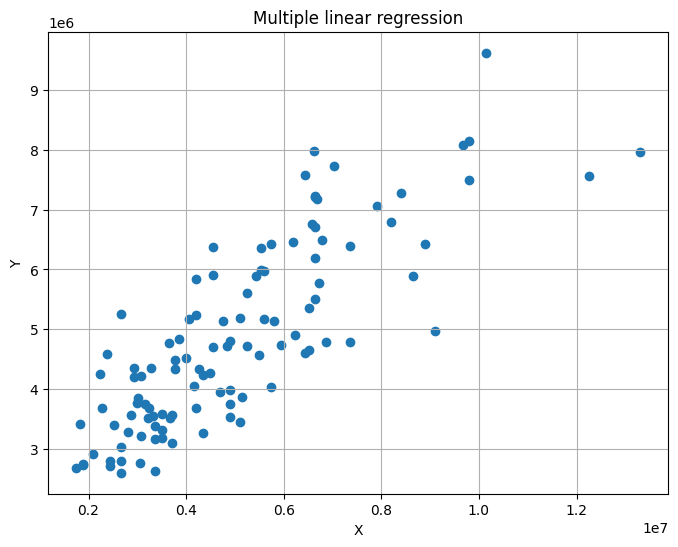

In [32]:
plt.figure(figsize=(8,6))
plt.scatter(Y_test,Y_predict)
plt.title("Multiple linear regression")
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True)
plt.show()